In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [2]:
DT = 1
Q0 = 17921.57581 

In [277]:
def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    return df

path = f'2_merged_data'

data = read_data(path)
data['eta'] = - data['eta']  # Negate eta to match model convention
display(data)

,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,0.140783,0,-0.005763,-0.000471,0.996944
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415552,15.9,1.4,2404.0,2.588773,6.969502,0.494206,-2.285347,3.283184,0.694411,247,-0.020117,-0.000300,0.064722
415553,15.9,1.4,2405.0,2.568657,6.969502,0.493907,-2.285347,3.281990,0.713334,247,-0.020923,-0.000300,0.064333
415554,15.9,1.4,2406.0,2.547734,6.969502,0.493607,-2.285347,3.280796,0.733063,247,-0.021729,-0.000300,0.063944
415555,15.9,1.4,2407.0,2.526005,6.969502,0.493307,-2.285347,3.279602,0.753597,247,-0.021729,-0.000300,0.063556


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [278]:
# Batch data
feature_cols = ['I', 'u', 'soc', 'Ue']
target_cols  = ['V', 'F', 'eta']

# Trajectories have unequal length — pad to longest and store a mask
traj_lengths = data['trajectory'].value_counts().sort_index().values
B     = len(traj_lengths)  # number of trajectories
T_max = traj_lengths.max()
Cx    = len(feature_cols)
Cy    = len(target_cols)

X_batched = torch.zeros(B, T_max, Cx)
Y_batched = torch.zeros(B, T_max, Cy)
mask      = torch.zeros(B, T_max, dtype=torch.bool)   # True where data exists

# Group by trajectory and fill the batches (rest = 0 (padding), mask = False)
for traj_id, grp in data.sort_values(['trajectory','t']).groupby('trajectory'):
    t_len = len(grp)
    X_batched[traj_id, :t_len, ...] = torch.tensor(grp[feature_cols].values, dtype=torch.float32)
    Y_batched[traj_id, :t_len, ...] = torch.tensor(grp[target_cols].values, dtype=torch.float32)
    mask[traj_id,      :t_len] = True

print(f"X_batched : {X_batched.shape}  (padded, use mask for loss)")
print(f"mask      : {mask.shape}")

X_batched : torch.Size([248, 7049, 4])  (padded, use mask for loss)
mask      : torch.Size([248, 7049])


In [279]:
# Split
split   = int(B * 0.8)
X_train = X_batched[:split]   # (B_train, T, Cx)
Y_train = Y_batched[:split]   # (B_train, T, Cy)
X_test  = X_batched[split:]   # (B_test,  T, Cx)
Y_test  = Y_batched[split:]   # (B_test,  T, Cy)
mask_train = mask[:split]
mask_test  = mask[split:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


# DataLoaders
dataset_train = TensorDataset(X_train, Y_train, mask_train)
dataset_test  = TensorDataset(X_test,  Y_test, mask_test)

loader_train  = DataLoader(dataset_train, batch_size=X_train.shape[0]//4, shuffle=True)
loader_test   = DataLoader(dataset_test, batch_size=X_test.shape[0]//4, shuffle=False)

Train: torch.Size([198, 7049, 4])  |  Test: torch.Size([50, 7049, 4])


In [280]:
first_rx = data.groupby('u')['F'].first()
k = abs(first_rx / (data.groupby('u')['u'].first()))
print(k.values[0])

def R0_func(u, I):
    ''' 
    Finds the R0 value for given u and I 
    Adjusts voltage curve 
    '''
    return u * (-0.0001887521) - 7.049519e-5 * I + 0.008446693

def Mech_box(Fs, u, k=k.values[0]):
    """ F = Fs_NN(SoC) - k * delta_u """
    return Fs - k * u

def step(Fs, dFs, dt):
    return Fs + dt * dFs

0.5316441632537718


In [319]:
import torch.nn.functional as TF

def masked_mse(y_pred, y_target, mask):
    '''
    y_pred, y_true : (B, T_max)
    mask           : (B, T_max)      True where valid
    '''
    sq_err = (y_pred - y_target) ** 2
    return sq_err[mask].mean()  

class NeuralODE(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        # self.fs_dot_net = nn.Sequential(     
        #     nn.Linear(5, hidden_size),   # [Fs_t, I_t, u_t, soc_t]
        #     nn.ReLU(),
        #     nn.Linear(hidden_size, hidden_size),
        #     nn.ReLU(),
        #     nn.Linear(hidden_size, 1)   # output: dFs/dt
        # )
        # self.r0_net = nn.Sequential(
        #     nn.Linear(4, hidden_size),  # [I_t, u_t, soc_t]
        #     nn.ReLU(),
        #     nn.Linear(hidden_size, 1)
        # )
        self.rc_dot_net = nn.Sequential(
            nn.Linear(4, hidden_size),  # [V_rc_t, I_t, u_t, soc_t]
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def rc_rollout(self, x_b, V_rc0, mask=None):
        '''
        x_b   : (B, T, 4)  (I, u, soc, U_eq)
        V_rc0 : (B,)        initial RC voltage
        mask  : (B, T) bool — True where data is valid (not padding)
        '''
        V_rc = V_rc0
        V_rc_preds = []
        T = x_b.shape[1]

        for t in range(T):
            V_rc_preds.append(V_rc) # Neglect last entry

            ode_input = torch.cat([V_rc.unsqueeze(-1), x_b[:, t, :3]], dim=-1)  # (B, 5)     Fed with predicted value, not teacher forcing
            dV_rc = self.rc_dot_net(ode_input).squeeze(-1)                 # (B,)
            dV_rc = torch.clamp(dV_rc, -1.0, 0.0)
            # dV_rc = TF.relu(dV_rc)                        # Ensure non-negativity (B,)
            # dV_rc = TF.softplus(dV_rc)                                   # Ensure positivity (discharge) (B,)

            V_rc_new = step(V_rc, dV_rc, dt=DT)     # Compute new V_rc based on ODE step

            # On padded timesteps: freeze the state (don't let zeros corrupt V_rc)
            valid = mask[:, t]                                   # (B,) bool
            V_rc = torch.where(valid, V_rc_new, V_rc.detach())   # If valid return new, else keep old (no grad)

        return torch.stack(V_rc_preds, dim=1)   # (B, T)
    
    def eta_rollout(self, x_b, eta0, mask=None):
        state = eta0                         # (B,) — initialise from data, not zeros!
        preds = []
        for t in range(x_b.shape[1]):
            ode_input = torch.cat([state.unsqueeze(-1), x_b[:, t, :3]], dim=-1)
            d_state   = self.rc_dot_net(ode_input).squeeze(-1)
            d_state   = torch.clamp(d_state, -10.0, 10.0)
            new_state = state + d_state * DT
            valid     = mask[:, t]
            state     = torch.where(valid, new_state, state.detach())
            preds.append(state)
        return torch.stack(preds, dim=1)     # (B, T) — this IS eta_pred directly
    
    # –––– Case 1: eta = V_rc, teacher forcing on V_rc ─────────────────────
    def tf_loss_eta_direct(self, x_b, y_b, mask_b):
        '''
        Teacher forcing where the ODE state IS eta.
        deta/dt is predicted; teacher signal = finite difference of true eta.
        No R0 needed at all.
        '''
        eta_true = y_b[:, :, 2]   # (B, T)  positive

        # Target derivative from data
        d_eta_target = (eta_true[:, 1:] - eta_true[:, :-1]) / DT    # (B, T-1)   future eta - current eta

        # ODE input: [eta_true[t], I[t], u[t], U_eq[t], soc[t]]
        ode_input  = torch.cat([eta_true[:, :-1].unsqueeze(-1), x_b[:, :-1, :3]], dim=-1)   # (B, T-1, 4) fed with true eta for teacher forcing
        d_eta_pred = self.rc_dot_net(ode_input).squeeze(-1)         # (B, T-1)
        print(d_eta_pred)
        # d_eta_pred = TF.softplus(d_eta_pred)                      # Ensure positivity (B, T-1)
        # d_eta_pred = TF.relu(d_eta_pred)                        # Ensure non-negativity (B, T-1)

        # Predicted next state from teacher-forced current state
        eta_next_pred = eta_true[:, :-1] + d_eta_pred * DT              # (B, T-1)

        # derivative loss and state loss
        loss_deriv = masked_mse(d_eta_pred, d_eta_target, mask_b[:, 1:])
        loss_state = masked_mse(eta_next_pred, eta_true[:, 1:], mask_b[:, 1:])

        return loss_deriv + loss_state
    


    # –––– Case 2: eta = R0*I + V_rc, teacher forcing on V_rc
    def tf_loss_vrc(self, x_b, y_b, mask_b, R0_fixed=None):
        """
        Teacher forcing on the RC state only.
        Pass R0_fixed (scalar) to bootstrap, or None to use predicted R0.
        """
        I        = x_b[:, :, 0]
        u        = x_b[:, :, 1]
        eta_true = y_b[:, :, 2]   # (B, T)

        R0 = R0_func(u, I)
        V_rc_true = eta_true - R0 * I

        d_vrc_target = (V_rc_true[:, 1:] - V_rc_true[:, :-1]) / DT  # (B, T-1)

        ode_input  = torch.cat([V_rc_true[:, :-1].unsqueeze(-1), x_b[:, :-1, :3]], dim=-1)           # (B, T-1, 4)
        d_vrc_pred = self.rc_dot_net(ode_input).squeeze(-1)           # (B, T-1)
        d_vrc_pred = torch.clamp(d_vrc_pred, -1.0, 0.0)
        print(d_vrc_pred[:2])
        print(d_vrc_target[:2])
        # d_vrc_pred = TF.softplus(d_vrc_pred)                      # Ensure positivity (B, T-1)

        vrc_next = V_rc_true[:,:-1] + d_vrc_pred * DT
        loss_d = masked_mse(d_vrc_pred, d_vrc_target,       mask_b[:,1:])
        loss_s = masked_mse(vrc_next,   V_rc_true[:,1:],    mask_b[:,1:])
        return loss_d + loss_s
    

    def tf_loss_vrc_weighted(self, x_b, y_b, mask_b):
        I, u      = x_b[:,:,0], x_b[:,:,1]
        eta_true  = y_b[:,:,2]
        V_rc_true = eta_true - R0_func(u, I) * I

        d_vrc_target = (V_rc_true[:,1:] - V_rc_true[:,:-1]) / DT   # (B, T-1)

        ode_input  = torch.cat([V_rc_true[:,:-1].unsqueeze(-1), x_b[:,:-1,:3]], dim=-1)
        d_vrc_pred = self.rc_dot_net(ode_input).squeeze(-1)

        # Weight by magnitude of target — forces attention on the spike
        weights = (d_vrc_target.abs() + 1e-3)          # never zero
        weights = weights / weights[mask_b[:,1:]].mean()  # normalise

        sq_err  = (d_vrc_pred - d_vrc_target) ** 2
        loss_d  = (sq_err * weights)[mask_b[:,1:]].mean()

        # State loss unchanged
        vrc_next = V_rc_true[:,:-1] + d_vrc_pred * DT
        loss_s   = masked_mse(vrc_next, V_rc_true[:,1:], mask_b[:,1:])

        return 0.5 * loss_d + loss_s
    
    def tf_loss_with_scheduled_sampling(self, x_b, y_b, mask_b, teacher_ratio=1.0):
        """
        teacher_ratio=1.0 - pure teacher forcing
        teacher_ratio=0.0 - pure rollout (self-fed)
        Anneal teacher_ratio toward 0 over training.
        """
        eta_true = y_b[:, :, 2]          # (B, T)
        B, T, _ = x_b.shape

        state = eta_true[:, 0]            # always start from true initial state
        preds = []

        for t in range(T - 1):
            ode_input  = torch.cat([state.unsqueeze(-1), x_b[:, t, :3]], dim=-1)  # (B, 5)
            d_eta_raw = self.rc_dot_net(ode_input).squeeze(-1)                   # (B,)
            d_eta_pred = TF.softplus(d_eta_raw)                                # Ensure negativity (discharge) (B, T-1)
            eta_next_pred = state + d_eta_pred * DT                               # Euler step

            # Scheduled sampling: mix true and predicted next state
            use_true = torch.rand(B, device=x_b.device) < teacher_ratio           # (B,) bool
            state    = torch.where(use_true, eta_true[:, t + 1], eta_next_pred)

            preds.append(eta_next_pred)   # always record the prediction, not the mixed state

        eta_pred_seq = torch.stack(preds, dim=1)                                  # (B, T-1)
        d_eta_target = (eta_true[:, 1:] - eta_true[:, :-1]) / DT                 # (B, T-1)

        return masked_mse(eta_pred_seq, eta_true[:, 1:], mask_b[:, 1:])           # predict next eta directly


    def forward(self, x_b, eta0, mask=None, dt=2.0):
        I = x_b[:, :, 0]    # (B, T)
        u = x_b[:, :, 1]    # (B, T)
        U_eq = x_b[:, :, 3] # (B, T)

        ''' Rollout forward pass '''
        eta     = self.eta_rollout(x_b, eta0, mask)  # (B, T)
        eta_pred = eta
        V_pred   = U_eq - eta_pred

        ''' Rollout forward pass w. R0_function '''
        # V_rc0    = torch.zeros(x_b.shape[0])  # start with zero RC voltage
        # V_rc     = self.rc_rollout(x_b, V_rc0, mask)  # (B, T)
        # eta_pred = R0_func(u, I) * I + V_rc
        # V_pred   = U_eq - eta_pred

        return V_pred, eta_pred, eta#, F_pred

model = NeuralODE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [320]:
def training(epochs):
    history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}
    tot_time = 0.
    model.train()
    for ep in range(epochs):
        start_t      = time.perf_counter()
        ep_loss      = 0.0
        teacher_ratio = max(0.0, 1.0 - ep / epochs)  # Linear decay from 1 to 0

        for x_b, y_b, mask_b in loader_train:
            # loss = model.tf_loss_eta_direct(x_b, y_b, mask_b)  # pure teacher forcing on eta, no R0 needed
            # loss = model.tf_loss_vrc(x_b, y_b, mask_b)  # teacher forcing on V_rc, with R0 function
            # loss = model.tf_loss_vrc_weighted(x_b, y_b, mask_b)
            loss = model.tf_loss_with_scheduled_sampling(x_b, y_b, mask_b, teacher_ratio)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_loss += loss.item()            

        ep_loss /= len(loader_train)
        history["loss"].append(ep_loss)

        end_t     = time.perf_counter()
        tot_time += end_t - start_t
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')
        if tot_time > 10 * 60:
            print("Early stopping.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.2e} | teacher_ratio {teacher_ratio:.2f} | time {end_t-start_t:.2f}s")

    return history

In [321]:
history = training(epochs=10)

ETA: 0.87 min
Epoch 1 | loss 1.77e-01 | teacher_ratio 1.00 | time 5.23s
Epoch 2 | loss 2.01e-02 | teacher_ratio 0.90 | time 4.98s
Epoch 3 | loss 6.19e-03 | teacher_ratio 0.80 | time 5.21s
Epoch 4 | loss 2.54e-03 | teacher_ratio 0.70 | time 5.30s
Epoch 5 | loss 1.42e-03 | teacher_ratio 0.60 | time 5.18s
Epoch 6 | loss 1.09e-03 | teacher_ratio 0.50 | time 5.12s
Epoch 7 | loss 1.01e-03 | teacher_ratio 0.40 | time 4.83s
Epoch 8 | loss 1.12e-03 | teacher_ratio 0.30 | time 5.41s
Epoch 9 | loss 1.78e-03 | teacher_ratio 0.20 | time 5.30s
Epoch 10 | loss 3.88e-03 | teacher_ratio 0.10 | time 5.04s


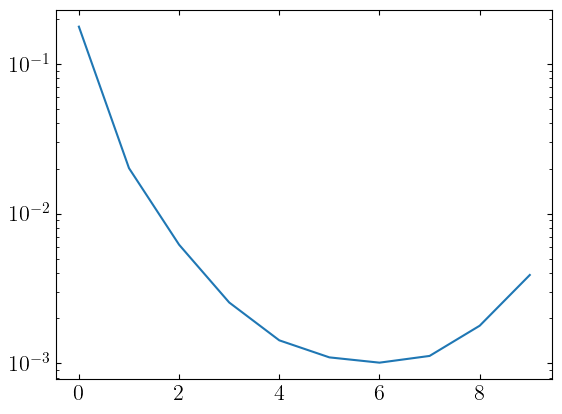

In [322]:
plt.semilogy(history["loss"], label="Total Loss")

[-8.789071e+00 -1.878907e+01 -2.878907e+01 ... -2.836879e+04 -2.837879e+04
 -2.838879e+04]


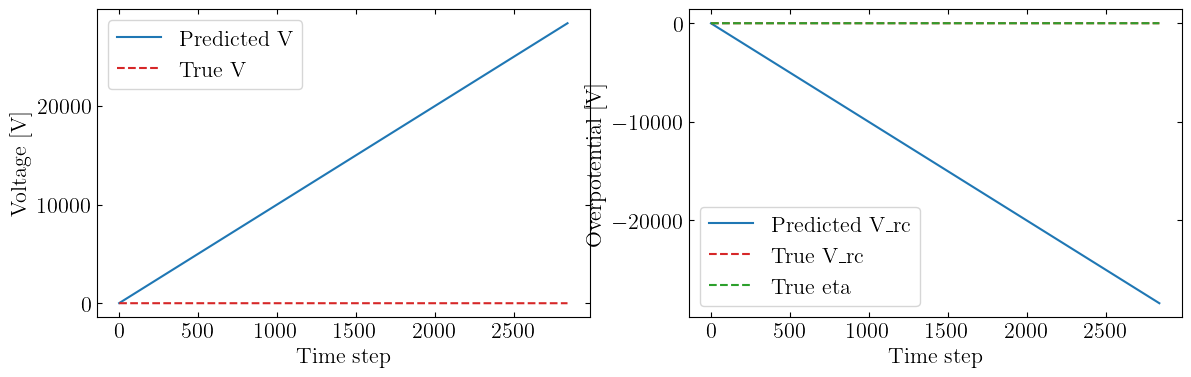

In [323]:
def evaluate(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:, :, 0]    # (B, T)
        U_eq = x_test[:, :, 2] # (B, T)

        B = x_test.shape[0]
        eta0 = y_test[:, 0, 2]    # (B,)
        V_rc0 = torch.zeros(B)

        # R0 = model.r_forward(x_test)
        V_pred, eta_pred, V_rc_pred = model(x_test, eta0, mask_test)  # (B, T)
        
        # V_pred = model(x_test, Fs0)  # (B, T)  # Using forward for V_pred directly
    
    return V_pred.detach().numpy(), eta_pred.detach().numpy(), V_rc_pred.detach().numpy()



V_pred, eta_pred, V_rc_pred = evaluate(model, X_test, Y_test)
V_rc_true = Y_test[:, :, 2] - R0_func(X_test[:, :, 1], X_test[:, :, 0]) * X_test[:, :, 0]

idx = 0
t_max = mask_test[idx].sum()

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(V_pred[idx, :t_max], color=colors[0], label="Predicted V")
axs[0].plot(Y_test[idx, :t_max, 0], linestyle='--', color=colors[1], label="True V")
axs[0].legend()
axs[0].set_ylabel("Voltage [V]")
axs[0].set_xlabel("Time step")
axs[1].plot(V_rc_pred[idx, :t_max], color=colors[0], label="Predicted V_rc")
axs[1].plot(V_rc_true[idx, :t_max], linestyle='--', color=colors[1], label="True V_rc")
axs[1].plot(Y_test[idx, :t_max, 2], linestyle='--', color=colors[2], label="True eta")
axs[1].legend()
axs[1].set_ylabel("Overpotential [V]")
axs[1].set_xlabel("Time step")
# axs[1].plot(eta_pred[idx, :t_max], color=colors[0], label="Predicted eta")

print(V_rc_pred[idx, :t_max])

tensor([19.9129, -0.1437,  0.9989])
eta_true   min/max: 0.022504348307847977 1.2445180416107178
R0*I       min/max: 0.022492285817861557 0.1749487966299057
V_rc_true  min/max: -0.0021660327911376953 1.072819709777832
d_vrc_target min/max: -0.00035440921783447266 0.08550626039505005
fraction negative: 0.41085270047187805
R0*I as fraction of eta: 42.99%


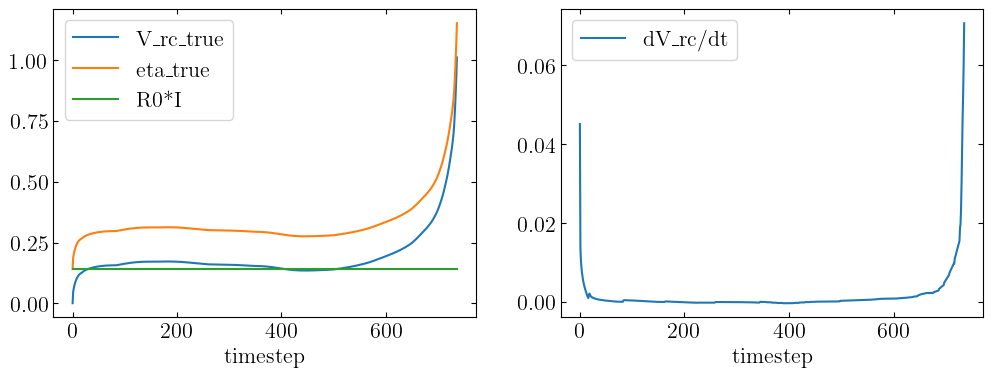

In [324]:
# Run this BEFORE training, on one batch
x_b, y_b, mask_b = next(iter(loader_train))

print(x_b[0, 0, :3])

I         = x_b[:, :, 0]
u         = x_b[:, :, 1]
eta_true  = y_b[:, :, 2]
R0        = R0_func(u, I)
V_rc_true = eta_true - R0 * I

print("eta_true   min/max:", eta_true[mask_b].min().item(),   eta_true[mask_b].max().item())
print("R0*I       min/max:", (R0*I)[mask_b].min().item(),     (R0*I)[mask_b].max().item())
print("V_rc_true  min/max:", V_rc_true[mask_b].min().item(),  V_rc_true[mask_b].max().item())

d_vrc = (V_rc_true[:, 1:] - V_rc_true[:, :-1]) / DT
print("d_vrc_target min/max:", d_vrc[mask_b[:,1:]].min().item(), d_vrc[mask_b[:,1:]].max().item())
print("fraction negative:",    (d_vrc[mask_b[:,1:]] < 0).float().mean().item())

# Plot V_rc_true for trajectory 0
idx   = 0
t_max = mask_b[idx].sum()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(V_rc_true[idx, :t_max].detach(), label='V_rc_true')
axs[0].plot(eta_true[idx,  :t_max].detach(), label='eta_true')
axs[0].plot((R0*I)[idx,    :t_max].detach(), label='R0*I')
axs[1].plot(d_vrc[idx, :t_max-1].detach(), label='dV_rc/dt')
axs[0].legend(); axs[0].set_xlabel("timestep");
axs[1].legend(); axs[1].set_xlabel("timestep");

frac = (R0 * I)[mask_b].mean() / eta_true[mask_b].mean()
print(f"R0*I as fraction of eta: {frac:.2%}")   # expect ~30-70%